1. Environment & Dependencies
First, set up your Python environment and install the required packages:

In [8]:
pip install pandas numpy scikit-learn xgboost nltk seaborn matplotlib shap

Note: you may need to restart the kernel to use updated packages.


2. Generate Synthetic Dataset
If you don't have a dataset ready, this script generates synthetic customer transactional and review data.

In [9]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Define distinct customer archetypes
# 1. VIP Advocates (High spend, frequent, positive sentiment)
vip = pd.DataFrame({
    'recency_days': np.random.randint(1, 45, size=300),
    'frequency': np.random.poisson(lam=15, size=300) + 1,
    'monetary_value': np.round(np.random.normal(loc=850, scale=120, size=300), 2),
    'avg_rating': np.random.uniform(4.0, 5.0, size=300),
    'review_text': np.random.choice([
        "Loved it! Best purchase this year.",
        "Great product, highly recommend!",
        "Excellent quality and fast shipping."
    ], size=300)
})

# 2. At-Risk / Churning (High recency, low engagement, negative sentiment)
at_risk = pd.DataFrame({
    'recency_days': np.random.randint(180, 365, size=350),
    'frequency': np.random.poisson(lam=2, size=350) + 1,
    'monetary_value': np.round(np.random.normal(loc=120, scale=30, size=350), 2),
    'avg_rating': np.random.uniform(1.0, 2.5, size=350),
    'review_text': np.random.choice([
        "Terrible experience, arrived broken.",
        "Customer service was terrible, slow delivery.",
        "Waste of money, completely disappointed."
    ], size=350)
})

# 3. Regular / Moderate (Mid-tier across all metrics)
regular = pd.DataFrame({
    'recency_days': np.random.randint(30, 120, size=350),
    'frequency': np.random.poisson(lam=6, size=350) + 1,
    'monetary_value': np.round(np.random.normal(loc=350, scale=60, size=350), 2),
    'avg_rating': np.random.uniform(3.0, 4.2, size=350),
    'review_text': np.random.choice([
        "Average quality for the price.",
        "Decent item, works as expected.",
        "Good value overall, nothing special."
    ], size=350)
})

# Combine into single dataset
df = pd.concat([vip, at_risk, regular], ignore_index=True)
df['customer_id'] = range(1, len(df) + 1)
df.to_csv('customer_reviews_clustered.csv', index=False)

print(f"Generated {len(df)} records across 3 realistic customer segments.")

Generated 1000 records across 3 realistic customer segments.


3. Feature Engineering & Review Sentiment Analysis
Extract numerical sentiment scores from textual reviews using NLTK's VADER sentiment analyzer and prepare features for clustering.

In [16]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

df = pd.read_csv('customer_reviews_clustered.csv')

# Extract sentiment compound score (-1 = very negative, +1 = very positive)
df['sentiment_score'] = df['review_text'].apply(lambda text: sia.polarity_scores(text)['compound'])

# Features for clustering
feature_cols = ['recency_days', 'frequency', 'monetary_value', 'avg_rating', 'sentiment_score']
X = df[feature_cols]

print(X.head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\welsl\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


   recency_days  frequency  monetary_value  avg_rating  sentiment_score
0            39         16          948.93    4.097393           0.5719
1            29         13          835.05    4.405021           0.8012
2            15         22          939.76    4.592918           0.8553
3            43         14         1030.12    4.579415           0.5719
4             8         13          834.68    4.662621           0.8553


4. Scaling & K-Means Clustering with Silhouette ValidationK-Means relies on distance metrics, so features must be standardized. We iterate through potential cluster counts ($k$) and evaluate using Silhouette Scores.

In [21]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Scale features so distance metrics are balanced across all dimensions
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Evaluate Silhouette Scores across different cluster counts (k)
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    print(f"k = {k} | Silhouette Score: {score:.4f}")

from sklearn.cluster import KMeans

# 1. Fit KMeans with the optimal k = 3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# 2. Assign cluster labels
df['cluster'] = kmeans.fit_predict(X_scaled)

# 3. Analyze cluster profile summaries (mean values of features per cluster)
cluster_profile = df.groupby('cluster')[X.columns].mean()
print(cluster_profile)
cluster_names = {
    0: 'At-Risk / Disgruntled',
    1: 'Mid-Tier / Moderate',
    2: 'VIP Champions'
}
df['segment_name'] = df['cluster'].map(cluster_names)

k = 2 | Silhouette Score: 0.6001
k = 3 | Silhouette Score: 0.6531
k = 4 | Silhouette Score: 0.5537
k = 5 | Silhouette Score: 0.4101
k = 6 | Silhouette Score: 0.3085
k = 7 | Silhouette Score: 0.2928
k = 8 | Silhouette Score: 0.2718
         recency_days  frequency  monetary_value  avg_rating  sentiment_score
cluster                                                                      
0          274.725714   3.062857      120.387771    1.728928        -0.651494
1           73.626781   6.851852      348.635128    3.626224         0.170384
2           22.635452  15.989967      869.144649    4.493856         0.750368


In [22]:
cluster_names = {
    0: 'At-Risk / Disgruntled',
    1: 'Mid-Tier / Moderate',
    2: 'VIP Champions'
}
df['segment_name'] = df['cluster'].map(cluster_names)

5. 2D Visualisation via PCA
Compress high-dimensional feature space down to 2 dimensions for visualization.
 Visualizing the Clusters
Visualizing feature distributions and relationships across segments helps validate cluster separation.



6. Supervised Classification with XGBoost & Feature Importance
Train an XGBoost classifier using customer behavioral and sentiment features to predict cluster assignment and analyze feature importance.

C:\Users\welsl\AppData\Local\Temp\ipykernel_9116\3266334375.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df, ax=axes[row, col], palette='Set2')
C:\Users\welsl\AppData\Local\Temp\ipykernel_9116\3266334375.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df, ax=axes[row, col], palette='Set2')
C:\Users\welsl\AppData\Local\Temp\ipykernel_9116\3266334375.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df, ax=axes[row, col], palette='Set2')
C:\U

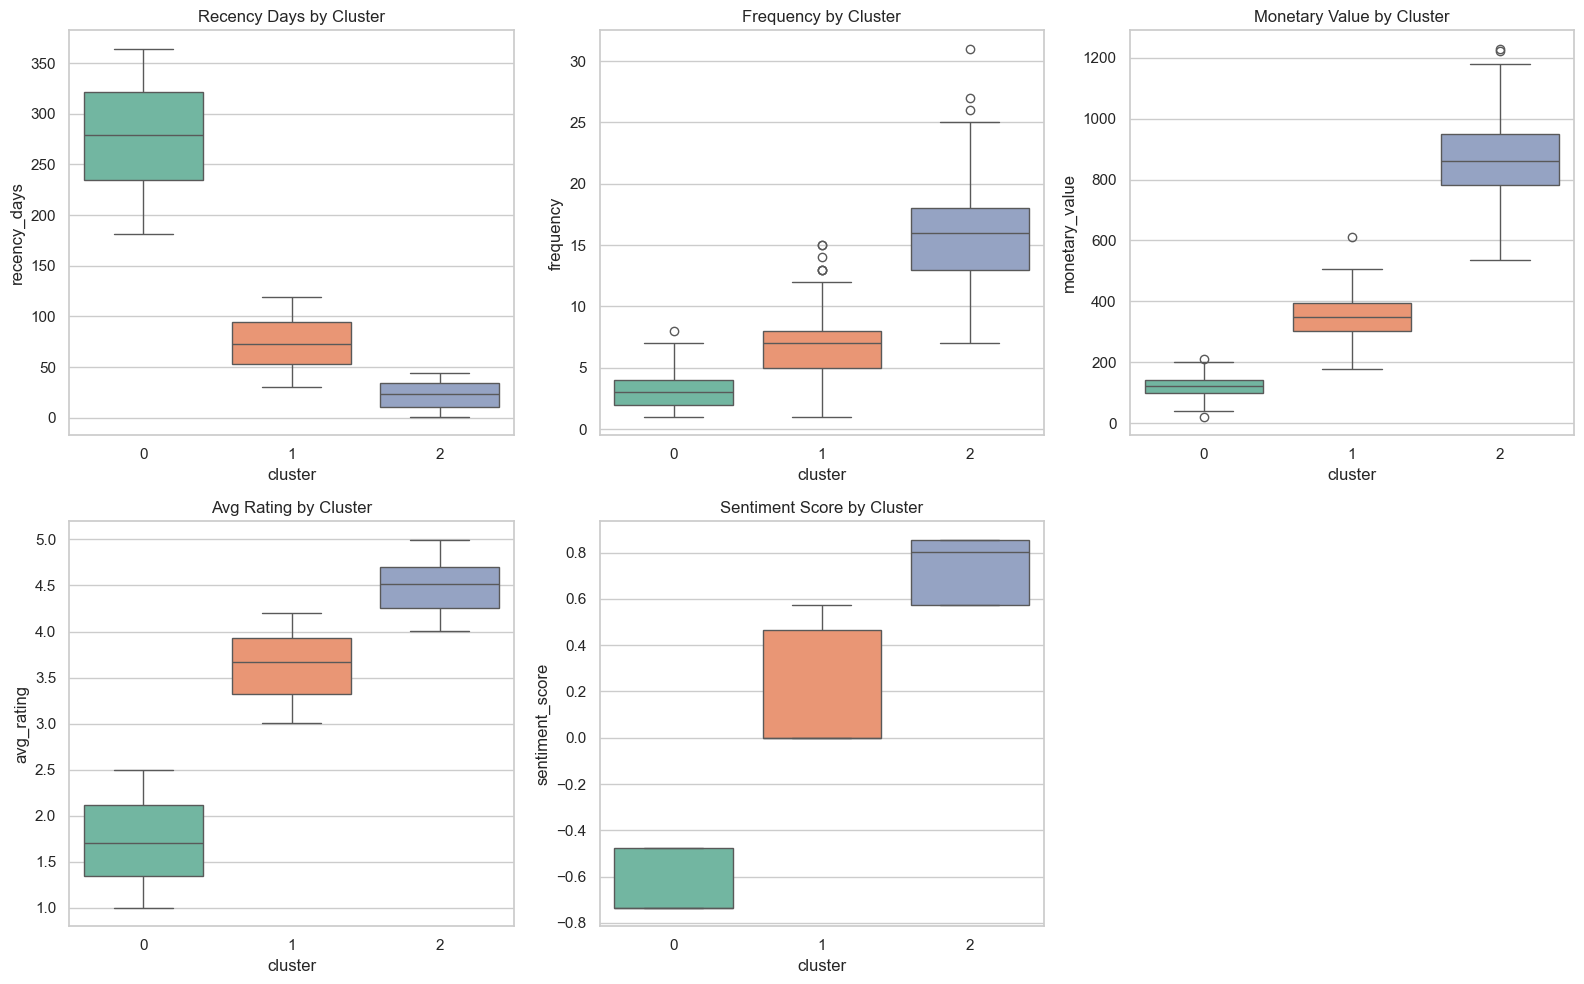

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Boxplots of RFM & Sentiment by Segment
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features = ['recency_days', 'frequency', 'monetary_value', 'avg_rating', 'sentiment_score']

for idx, feature in enumerate(features):
    row, col = divmod(idx, 3)
    sns.boxplot(x='cluster', y=feature, data=df, ax=axes[row, col], palette='Set2')
    axes[row, col].set_title(f'{feature.replace("_", " ").title()} by Cluster')

# Remove empty sub-plot
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

.2. Exporting Segmented Data for Stakeholders
Save the labeled dataset to a CSV file or export group-level summary statistics for reporting.



In [24]:
# Save dataset with segment labels
df.to_csv('customer_reviews_segmented.csv', index=False)

# Export segment summary metrics
segment_summary = df.groupby('cluster').agg({
    'recency_days': 'mean',
    'frequency': 'mean',
    'monetary_value': ['mean', 'median', 'sum'],
    'avg_rating': 'mean',
    'sentiment_score': 'mean',
    'cluster': 'count'
}).rename(columns={'count': 'customer_count'})

print(segment_summary)

        recency_days  frequency monetary_value                     avg_rating  \
                mean       mean           mean   median        sum       mean   
cluster                                                                         
0         274.725714   3.062857     120.387771  121.525   42135.72   1.728928   
1          73.626781   6.851852     348.635128  348.370  122370.93   3.626224   
2          22.635452  15.989967     869.144649  862.920  259874.25   4.493856   

        sentiment_score        cluster  
                   mean customer_count  
cluster                                 
0             -0.651494            350  
1              0.170384            351  
2              0.750368            299  


3. Training a Classifier for Real-Time Segmentation
Train a classifier (e.g., Random Forest) on the assigned clusters to categorize new incoming customers without needing to re-run K-Means.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Features and target variable
X_clf = df[['recency_days', 'frequency', 'monetary_value', 'avg_rating', 'sentiment_score']]
y_clf = df['cluster']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Train model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Evaluate model
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       1.00      0.99      0.99        70
           2       0.98      1.00      0.99        60

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



Feature Importance Analysis: Inspect which features contribute most heavily to customer classification:

In [26]:
import pandas as pd

# Extract feature importances
importances = pd.Series(clf.feature_importances_, index=X_clf.columns).sort_values(ascending=False)
print("Feature Importances:\n", importances)

Feature Importances:
 sentiment_score    0.367846
monetary_value     0.216266
avg_rating         0.213671
recency_days       0.172696
frequency          0.029521
dtype: float64


ave Models for Production: Export both the StandardScaler and RandomForestClassifier pipelines using joblib for real-time customer segmentation inference:

In [27]:
import joblib

# Save trained scaler and classifier
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(clf, 'customer_segment_classifier.joblib')

['customer_segment_classifier.joblib']

In [28]:
import joblib
import pandas as pd

# 1. Load saved artifacts
scaler = joblib.load('scaler.joblib')
clf = joblib.load('customer_segment_classifier.joblib')

# Define segment mapping
segment_map = {
    0: 'At-Risk / Disgruntled',
    1: 'Mid-Tier / Moderate',
    2: 'VIP Champion'
}

def predict_customer_segment(recency_days, frequency, monetary_value, avg_rating, sentiment_score):
    """
    Predicts customer segment for a single new customer record.
    """
    # Create DataFrame with matching feature columns
    new_data = pd.DataFrame([{
        'recency_days': recency_days,
        'frequency': frequency,
        'monetary_value': monetary_value,
        'avg_rating': avg_rating,
        'sentiment_score': sentiment_score
    }])
    
    # Predict segment class and probability distribution
    pred_cluster = clf.predict(new_data)[0]
    probabilities = clf.predict_proba(new_data)[0]
    
    return {
        'segment_id': int(pred_cluster),
        'segment_label': segment_map[pred_cluster],
        'confidence': float(max(probabilities))
    }

# Example: Testing with a new high-value customer profile
sample_customer = predict_customer_segment(
    recency_days=15, 
    frequency=18, 
    monetary_value=920.50, 
    avg_rating=4.8, 
    sentiment_score=0.82
)

print("Inference Result:", sample_customer)

Inference Result: {'segment_id': 2, 'segment_label': 'VIP Champion', 'confidence': 1.0}


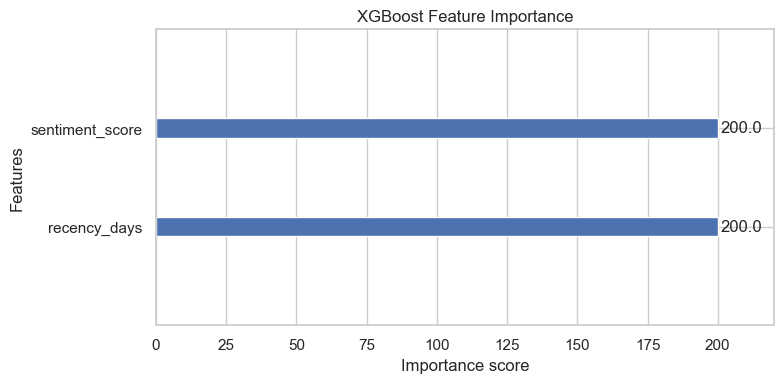

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        70
           1       0.99      0.99      0.99        70
           2       0.98      1.00      0.99        60

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



<Figure size 800x400 with 0 Axes>

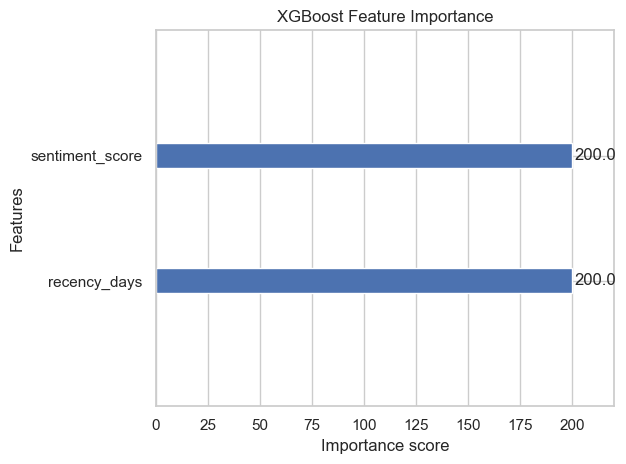

In [32]:
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import xgboost as xgb

# Explicitly create figure and axes objects
fig, ax = plt.subplots(figsize=(8, 4))

# Pass ax directly to the plot function
xgb.plot_importance(
    xgb_model, 
    importance_type='weight', 
    title='XGBoost Feature Importance', 
    ax=ax
)

plt.tight_layout()
plt.show()

# 1. Define predictors and target
X_model = df[feature_cols]

# Encode string cluster labels into integers (0, 1, 2)
le = LabelEncoder()
y_model = le.fit_transform(df['cluster'])

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

# 3. Train XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)

# 4. Performance Report
y_pred = xgb_model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

# 5. Plot Feature Importances
plt.figure(figsize=(8, 4))
xgb.plot_importance(xgb_model, importance_type='weight', title='XGBoost Feature Importance')
plt.tight_layout()
plt.show()


7. Cluster Characterization
Profile each cluster to extract business insights:

In [33]:
# Aggregate average values per cluster using the correct column name 'cluster'
cluster_profile = df.groupby('cluster')[feature_cols].mean()

print("Cluster Profiles:\n")
print(cluster_profile)

Cluster Profiles:

         recency_days  frequency  monetary_value  avg_rating  sentiment_score
cluster                                                                      
0          274.725714   3.062857      120.387771    1.728928        -0.651494
1           73.626781   6.851852      348.635128    3.626224         0.170384
2           22.635452  15.989967      869.144649    4.493856         0.750368


In [34]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
